# Calculus for ML
### Part of the *Math for ML* section — ML-CaPsule

> **Goal:** Understand derivatives, partial derivatives, and the chain rule — then connect them directly to the **GradientDescent/** folder already in this repo.

---

## 🗺️ What you'll learn

| Concept | ML Connection |
|---|---|
| Derivatives | Measuring how a loss changes when a weight changes |
| Partial Derivatives | Gradient — one for each weight in the model |
| Chain Rule | Backpropagation through layers |
| Gradient Descent | Putting it all together — connects to `GradientDescent/` folder |

---

## 📺 Watch first (optional but highly recommended)
[3Blue1Brown — Essence of Calculus](https://www.youtube.com/playlist?list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr)  
Chapter 1 and Chapter 3 are the most relevant. This notebook gives you the code to go alongside them.

---
## 1️⃣ What is a Derivative?

### Concept
The derivative of a function $f(x)$ at a point $x$ tells you:
> **"If I nudge $x$ by a tiny amount, how much does $f(x)$ change?"**

Formally:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

It is the **slope of the tangent line** at that point.

**ML connection:** The derivative of the **loss function** with respect to a **weight** tells us how much the loss would increase/decrease if we changed that weight slightly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A simple parabolic loss function: L(w) = w^2
def loss(w):
    return w ** 2

# Numerical derivative (finite difference)
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

# Analytical derivative of w^2 is 2w
w = 3.0
print(f"w = {w}")
print(f"Numerical derivative at w=3: {numerical_derivative(loss, w):.4f}")
print(f"Analytical derivative (2w):  {2 * w:.4f}")
print(f"Interpretation: if w increases by 1, the loss increases by ~{2*w:.1f}")

w = 3.0
Numerical derivative at w=3: 6.0000
Analytical derivative (2w):  6.0000
Interpretation: if w increases by 1, the loss increases by ~6.0


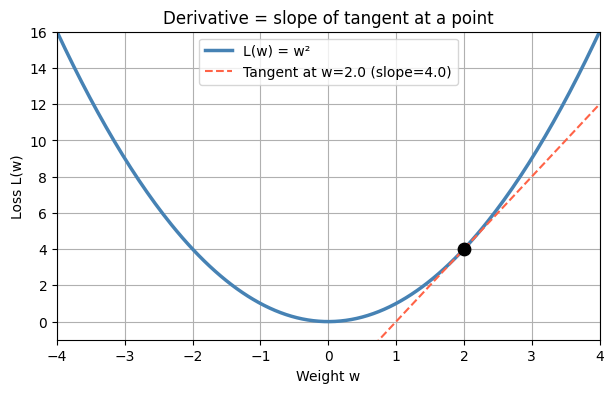

In [2]:
# Visualise the derivative as the slope of the tangent
w_vals = np.linspace(-4, 4, 200)
L_vals = loss(w_vals)

w0 = 2.0
slope = 2 * w0  # analytical derivative
tangent = loss(w0) + slope * (w_vals - w0)

plt.figure(figsize=(7, 4))
plt.plot(w_vals, L_vals, 'steelblue', linewidth=2.5, label='L(w) = w²')
plt.plot(w_vals, tangent, 'tomato', linewidth=1.5, linestyle='--', label=f'Tangent at w={w0} (slope={slope})')
plt.scatter([w0], [loss(w0)], color='black', s=80, zorder=5)
plt.ylim(-1, 16); plt.xlim(-4, 4)
plt.xlabel('Weight w'); plt.ylabel('Loss L(w)')
plt.title("Derivative = slope of tangent at a point")
plt.legend(); plt.grid(True); plt.show()

---
## 2️⃣ Partial Derivatives

### Concept
When a function has **multiple inputs** (like a model with many weights), we take the **partial derivative** with respect to each input, one at a time — holding all others constant.

$$\frac{\partial L}{\partial w_1} \quad \frac{\partial L}{\partial w_2} \quad \ldots$$

Together, all partial derivatives form the **gradient**:

$$\nabla L = \begin{bmatrix} \frac{\partial L}{\partial w_1} \\ \frac{\partial L}{\partial w_2} \end{bmatrix}$$

**ML connection:** With two weights $w_1, w_2$, the gradient tells us the direction of **steepest ascent** in loss space. We go the **opposite direction** to minimise loss.

In [3]:
# Loss with two weights: L(w1, w2) = w1^2 + 2*w2^2
def loss_2d(w1, w2):
    return w1**2 + 2*w2**2

# Partial derivatives:
# dL/dw1 = 2*w1
# dL/dw2 = 4*w2

w1, w2 = 3.0, 1.5
dL_dw1 = 2 * w1  # analytical
dL_dw2 = 4 * w2  # analytical

print(f"At (w1={w1}, w2={w2}):")
print(f"  ∂L/∂w1 = {dL_dw1}  (how much loss changes if w1 nudged)")
print(f"  ∂L/∂w2 = {dL_dw2}  (how much loss changes if w2 nudged)")
print(f"  Gradient ∇L = [{dL_dw1}, {dL_dw2}]")
print(f"  The gradient points toward INCREASING loss.")
print(f"  To DECREASE loss, move in the opposite direction: [{-dL_dw1}, {-dL_dw2}]")

At (w1=3.0, w2=1.5):
  ∂L/∂w1 = 6.0  (how much loss changes if w1 nudged)
  ∂L/∂w2 = 6.0  (how much loss changes if w2 nudged)
  Gradient ∇L = [6.0, 6.0]
  The gradient points toward INCREASING loss.
  To DECREASE loss, move in the opposite direction: [-6.0, -6.0]


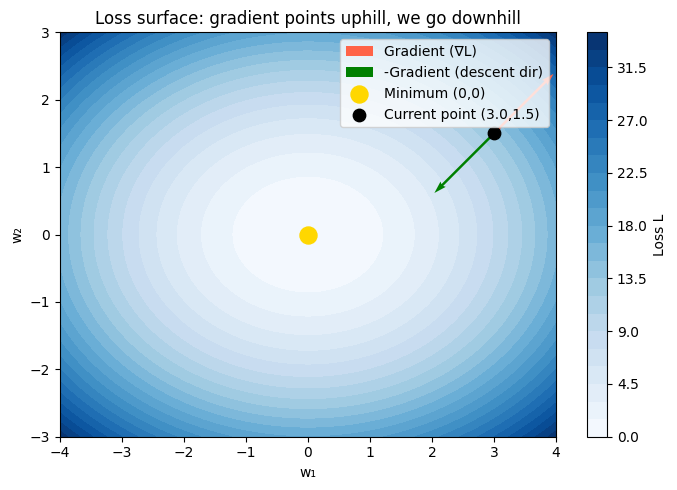

In [4]:
# Visualise the loss surface and gradient
w1_vals = np.linspace(-4, 4, 100)
w2_vals = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
L = loss_2d(W1, W2)

fig, ax = plt.subplots(figsize=(7, 5))
contour = ax.contourf(W1, W2, L, levels=30, cmap='Blues')
plt.colorbar(contour, ax=ax, label='Loss L')

# Plot the gradient arrow at (3, 1.5)
ax.quiver(w1, w2, dL_dw1, dL_dw2, color='tomato', scale=50, width=0.005, label='Gradient (∇L)')
ax.quiver(w1, w2, -dL_dw1, -dL_dw2, color='green', scale=50, width=0.005, label='-Gradient (descent dir)')
ax.scatter([0], [0], color='gold', s=150, zorder=5, label='Minimum (0,0)')
ax.scatter([w1], [w2], color='black', s=80, zorder=5, label=f'Current point ({w1},{w2})')
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.set_title('Loss surface: gradient points uphill, we go downhill')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

---
## 3️⃣ The Chain Rule

### Concept
If a function is **composed** of other functions, the chain rule lets us compute its derivative:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

Or in the notation you'll see in ML:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w}$$

**ML connection:** A neural network is a chain of composed functions. **Backpropagation is just the chain rule applied layer by layer**, from the output back to the inputs.

In [5]:
# Chain rule example: a simple 1-layer network
# Forward pass:  z = w * x + b,   y_hat = sigmoid(z),   L = (y - y_hat)^2

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)   # handy closed form

# Values
x = 2.0;  w = 0.5;  b = 0.1;  y = 1.0

# --- Forward pass ---
z     = w * x + b
y_hat = sigmoid(z)
L     = (y - y_hat) ** 2

print("=== Forward pass ===")
print(f"z     = w*x + b          = {z:.4f}")
print(f"y_hat = sigmoid(z)       = {y_hat:.4f}")
print(f"L     = (y - y_hat)^2   = {L:.4f}")

# --- Backward pass (chain rule) ---
dL_dyhat = -2 * (y - y_hat)                    # ∂L/∂ŷ
dyhat_dz = sigmoid_derivative(z)               # ∂ŷ/∂z
dz_dw    = x                                   # ∂z/∂w

# Chain rule: ∂L/∂w = ∂L/∂ŷ · ∂ŷ/∂z · ∂z/∂w
dL_dw = dL_dyhat * dyhat_dz * dz_dw

print("\n=== Backward pass (chain rule) ===")
print(f"∂L/∂ŷ  = -2(y - ŷ)      = {dL_dyhat:.4f}")
print(f"∂ŷ/∂z  = sigmoid'(z)    = {dyhat_dz:.4f}")
print(f"∂z/∂w  = x              = {dz_dw:.4f}")
print(f"∂L/∂w  = {dL_dyhat:.4f} × {dyhat_dz:.4f} × {dz_dw:.4f} = {dL_dw:.4f}")
print(f"\nThis tells us: nudging w by +0.01 changes the loss by ~{dL_dw*0.01:.4f}")

=== Forward pass ===
z     = w*x + b          = 1.1000
y_hat = sigmoid(z)       = 0.7503
L     = (y - y_hat)^2   = 0.0624

=== Backward pass (chain rule) ===
∂L/∂ŷ  = -2(y - ŷ)      = -0.4995
∂ŷ/∂z  = sigmoid'(z)    = 0.1874
∂z/∂w  = x              = 2.0000
∂L/∂w  = -0.4995 × 0.1874 × 2.0000 = -0.1872

This tells us: nudging w by +0.01 changes the loss by ~-0.0019


---
## 4️⃣ Gradient Descent — Putting It Together

### Concept
**Gradient Descent** uses the gradient to iteratively update weights to minimise the loss:

$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}$$

where $\alpha$ (alpha) is the **learning rate** — how big a step we take each iteration.

> **🔗 This connects directly to the `GradientDescent/` folder in this repo.**  
> That folder shows gradient descent applied to real datasets. This notebook gives you the mathematical foundation for why every line of that code works.

In [7]:
# Gradient Descent from scratch on a simple loss: L(w) = w^2
# dL/dw = 2w  (minimum is at w=0)

def grad(w):
    return 2 * w

learning_rate = 0.1
w = 4.0         # starting point
history = [w]

for step in range(20):
    w = w - learning_rate * grad(w)   # gradient descent update
    history.append(w)

print("Gradient Descent on L(w) = w²")
print(f"Start: w = 4.0,  Loss = {4.0**2:.2f}")
print(f"End:   w = {history[-1]:.5f},  Loss = {history[-1]**2:.6f}")
print(f"True minimum: w = 0 ")

Gradient Descent on L(w) = w²
Start: w = 4.0,  Loss = 16.00
End:   w = 0.04612,  Loss = 0.002127
True minimum: w = 0 


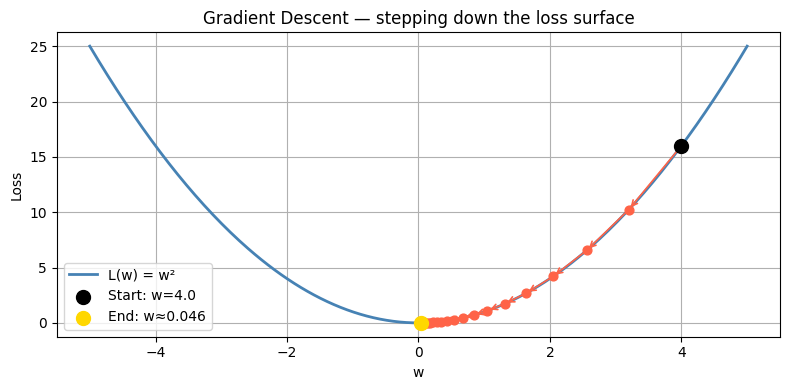

In [8]:
# Visualise the descent
w_vals = np.linspace(-5, 5, 300)
L_vals = w_vals ** 2

plt.figure(figsize=(8, 4))
plt.plot(w_vals, L_vals, 'steelblue', linewidth=2, label='L(w) = w²')
for i, wi in enumerate(history):
    plt.scatter(wi, wi**2, color='tomato', s=40, zorder=3)
    if i < len(history) - 1:
        plt.annotate('', xy=(history[i+1], history[i+1]**2),
                     xytext=(wi, wi**2),
                     arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2))
plt.scatter(history[0], history[0]**2, color='black', s=100, zorder=5, label=f'Start: w={history[0]}')
plt.scatter(history[-1], history[-1]**2, color='gold', s=100, zorder=5, label=f'End: w≈{history[-1]:.3f}')
plt.xlabel('w'); plt.ylabel('Loss'); plt.title('Gradient Descent — stepping down the loss surface')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

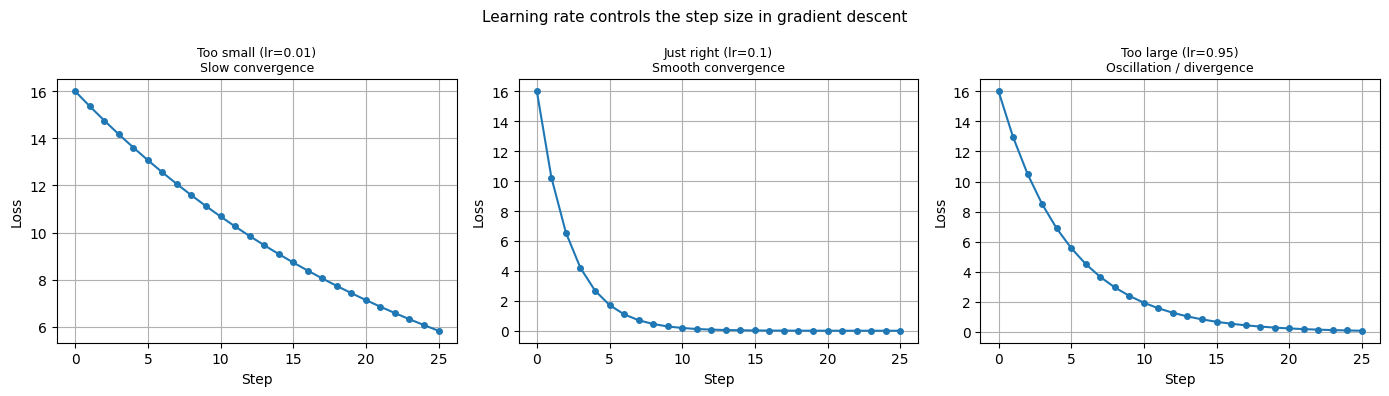

In [9]:
# Effect of learning rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
learning_rates = [0.01, 0.1, 0.95]
titles = ['Too small (lr=0.01)\nSlow convergence', 'Just right (lr=0.1)\nSmooth convergence', 'Too large (lr=0.95)\nOscillation / divergence']

for ax, lr, title in zip(axes, learning_rates, titles):
    w = 4.0
    hist = [w]
    for _ in range(25):
        w = w - lr * 2 * w
        hist.append(w)
    ax.plot(range(len(hist)), [wi**2 for wi in hist], marker='o', markersize=4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.grid(True)

plt.suptitle('Learning rate controls the step size in gradient descent', fontsize=11)
plt.tight_layout(); plt.show()

---
##  What comes next?

You now understand the calculus behind gradient descent.  
**Go explore the `GradientDescent/` folder** — every update rule there is the equation `w = w - lr * gradient` you just implemented.

**Next notebook:** [03_Probability_for_ML.ipynb](03_Probability_for_ML.ipynb) — learn the probability theory behind Naive Bayes.

---

## 📝 Summary

| Concept | Formula | ML use |
|---|---|---|
| Derivative | $f'(x) = \lim_{h→0}\frac{f(x+h)-f(x)}{h}$ | Slope of loss w.r.t. one weight |
| Partial derivative | $\frac{\partial L}{\partial w_i}$ | Gradient component for weight $w_i$ |
| Chain rule | $\frac{dL}{dw} = \frac{dL}{d\hat{y}} \cdot \frac{d\hat{y}}{dw}$ | Backpropagation through layers |
| Gradient Descent | $w \leftarrow w - \alpha \nabla L$ | Training any ML model |

---
📺 **Deepen your intuition:** [3Blue1Brown — Essence of Calculus](https://www.youtube.com/playlist?list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr)